# Retail Sales Analysis 2019

## Project Overview

This project analyzes retail sales transactions from 2019 to identify sales trends, customer purchasing behavior and revenue drivers.

## Business Objectives

The goal of this analysis is to explore retail sales transactions from 2019 and identify key business insights.

Main objectives:

- Identify top-selling and highest-revenue products
- Analyze sales trends throughout the year
- Understand customer purchasing behavior
- Detect seasonal sales patterns
- Explore time-based purchasing activity
- Derive business recommendations from the findings

## Dataset Overview

The dataset contains retail sales transactions recorded during 2019.

Each record represents a purchased product and includes information about:

- Order ID
- Product Name
- Quantity Ordered
- Unit Price
- Order Date and Time
- Purchase Address

The dataset contains 197,545 transaction records and serves as the foundation for all subsequent cleaning, transformation and analytical steps.

## Dataset Overview

The dataset contains retail sales transactions recorded during 2019.

Each record represents a purchased product and includes information about:

- Order ID
- Product Name
- Quantity Ordered
- Unit Price
- Order Date and Time
- Purchase Address

The dataset contains 197,545 transaction records and serves as the foundation for all subsequent cleaning, transformation and analytical steps.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

# Load dataset
df_sales = pd.read_csv("sales_data.csv")

## Required Libraries

This project requires the following Python libraries:

- pandas
- numpy
- matplotlib
- seaborn
- statsmodels

In [2]:
# Initial data preview
display(df_sales.head())

# Dataset structure
df_sales.info()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,248151,AA Batteries (4-pack),4,3.84,09/17/19 14:44,"380 North St, Los Angeles, CA 90001"
1,248152,USB-C Charging Cable,2,11.95,09/29/19 10:19,"511 8th St, Austin, TX 73301"
2,248153,USB-C Charging Cable,1,11.95,09/16/19 17:48,"151 Johnson St, Los Angeles, CA 90001"
3,248154,27in FHD Monitor,1,149.99,09/27/19 07:52,"355 Hickory St, Seattle, WA 98101"
4,248155,USB-C Charging Cable,1,11.95,09/01/19 19:03,"125 5th St, Atlanta, GA 30301"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197545 entries, 0 to 197544
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Order ID          197545 non-null  int64  
 1   Product           197545 non-null  object 
 2   Quantity Ordered  197545 non-null  int64  
 3   Price Each        197545 non-null  float64
 4   Order Date        197545 non-null  object 
 5   Purchase Address  197545 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 9.0+ MB


### Dataset Summary

The dataset contains **197,545 transaction records** and **6 columns**.

| Column | Description |
|----------|-------------|
| Order ID | Unique identifier for each order |
| Product | Purchased product |
| Quantity Ordered | Number of units ordered |
| Price Each | Unit price of the product |
| Order Date | Date and time of purchase |
| Purchase Address | Customer purchase address |

### Initial Observations

- No missing values were detected.
- The dataset contains a mix of numerical and categorical attributes.
- `Order Date` is currently stored as an object and requires conversion to a datetime format.
- Purchase addresses can be used to derive geographical information such as cities.

# Data Cleaning & Preparation

The following preprocessing steps were performed:

- Checked for missing values
- Converted date columns to datetime format
- Extracted city information from purchase addresses
- Created derived columns:
  - Total Sales
  - Month
- Removed duplicate records
- Reset the DataFrame index

In [3]:
print(df_sales.isnull().sum())

Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
dtype: int64


### Missing Values

No missing values were detected in any column.

In [4]:
# Convert Order Date to datetime
df_sales_cleaned = df_sales.copy()

df_sales_cleaned["Order Date"] = pd.to_datetime(
    df_sales_cleaned["Order Date"],
    format="%m/%d/%y %H:%M",
    errors="coerce"
)

### Date Conversion

The `Order Date` column was converted to datetime format to enable time-based analyses.

No invalid date values were generated during the conversion process.

In [5]:
# Create additional features for analysis
df_sales_cleaned["City"] = df_sales_cleaned["Purchase Address"].str.split(", ").str[1]
df_sales_cleaned[["Purchase Address", "City"]].head()
df_sales_cleaned["Total Sales"] = (df_sales_cleaned["Quantity Ordered"] * df_sales_cleaned["Price Each"])
df_sales_cleaned["Month"] = df_sales_cleaned["Order Date"].dt.to_period("M")
df_sales_cleaned.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,City,Total Sales,Month
0,248151,AA Batteries (4-pack),4,3.84,2019-09-17 14:44:00,"380 North St, Los Angeles, CA 90001",Los Angeles,15.36,2019-09
1,248152,USB-C Charging Cable,2,11.95,2019-09-29 10:19:00,"511 8th St, Austin, TX 73301",Austin,23.90,2019-09
2,248153,USB-C Charging Cable,1,11.95,2019-09-16 17:48:00,"151 Johnson St, Los Angeles, CA 90001",Los Angeles,11.95,2019-09
3,248154,27in FHD Monitor,1,149.99,2019-09-27 07:52:00,"355 Hickory St, Seattle, WA 98101",Seattle,149.99,2019-09
4,248155,USB-C Charging Cable,1,11.95,2019-09-01 19:03:00,"125 5th St, Atlanta, GA 30301",Atlanta,11.95,2019-09


### Feature Engineering

Additional columns were created to support later analyses.

New features include:

- **City** extracted from the purchase address for geographic analysis
- **Total Sales** calculated as Quantity Ordered × Price Each
- **Month** derived from the order date to support monthly trend analysis

These features provide the basis for sales, product, seasonal, and location-based analyses throughout the project.

In [6]:
# Count duplicate records

duplicate_count = df_sales.duplicated().sum()
duplicate_count

np.int64(11893)

In [7]:
# Remove duplicate records

df_sales_cleaned = df_sales_cleaned.drop_duplicates().copy()

# Check dataset structure after cleaning
df_sales_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185652 entries, 0 to 185915
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order ID          185652 non-null  int64         
 1   Product           185652 non-null  object        
 2   Quantity Ordered  185652 non-null  int64         
 3   Price Each        185652 non-null  float64       
 4   Order Date        185652 non-null  datetime64[ns]
 5   Purchase Address  185652 non-null  object        
 6   City              185652 non-null  object        
 7   Total Sales       185652 non-null  float64       
 8   Month             185652 non-null  period[M]     
dtypes: datetime64[ns](1), float64(2), int64(2), object(3), period[M](1)
memory usage: 14.2+ MB


### Duplicate Removal

Duplicate records were identified within the dataset and removed to prevent double-counting of sales transactions.

A total of **11,893 duplicate rows** were detected and removed during the cleaning process.

After removing duplicates, the dataset contained **185,652 unique records**, providing a reliable foundation for further analysis..

In [8]:
# Reset index after removing duplicates
df_sales_cleaned.reset_index(drop=True, inplace=True)

# Preview cleaned dataset
df_sales_cleaned.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,City,Total Sales,Month
0,248151,AA Batteries (4-pack),4,3.84,2019-09-17 14:44:00,"380 North St, Los Angeles, CA 90001",Los Angeles,15.36,2019-09
1,248152,USB-C Charging Cable,2,11.95,2019-09-29 10:19:00,"511 8th St, Austin, TX 73301",Austin,23.90,2019-09
2,248153,USB-C Charging Cable,1,11.95,2019-09-16 17:48:00,"151 Johnson St, Los Angeles, CA 90001",Los Angeles,11.95,2019-09
3,248154,27in FHD Monitor,1,149.99,2019-09-27 07:52:00,"355 Hickory St, Seattle, WA 98101",Seattle,149.99,2019-09
4,248155,USB-C Charging Cable,1,11.95,2019-09-01 19:03:00,"125 5th St, Atlanta, GA 30301",Atlanta,11.95,2019-09


### Index Reset

After removing duplicate records, the DataFrame index contained gaps because rows had been deleted.

The index was reset to create a clean and continuous numbering scheme, improving readability and ensuring consistent row references for subsequent analyses.

## Data Cleaning & Transformation Summary

The data preparation process included the following steps:

- Checked the dataset for missing values
- Converted the **Order Date** column to datetime format
- Extracted **City** information from the purchase address
- Calculated **Total Sales** as Quantity Ordered × Price Each
- Derived a **Month** feature from the order date
- Identified and removed duplicate records
- Reset the index after data cleaning

After the cleaning process, the dataset contained **185,652 unique transaction records** and was ready for exploratory data analysis.

The newly created features provide the foundation for temporal, geographical, and revenue-based analyses throughout the project.

---

## **# Descriptive Statistics and KPI Calculation**

## Business Metrics

To better understand overall sales performance, several key business metrics were calculated:

- Total revenue generated in 2019
- Average order value
- Number of orders per month
- Best-selling products based on sales volume and revenue
- Customers with the highest purchase volume

These KPIs provide an initial overview of sales performance and customer purchasing behavior.

In [9]:
# Summary statistics for numerical variables
df_sales_cleaned.describe()

,Order ID,Quantity Ordered,Price Each,Order Date,Total Sales
count,185652.000000,185652.000000,185652.000000,185652,185652.000000
mean,230397.332299,1.124529,184.507245,2019-07-18 20:48:16.720315136,185.599227
min,141234.000000,1.000000,2.990000,2019-01-01 03:07:00,2.990000
25%,185824.750000,1.000000,11.950000,2019-04-16 20:51:00,11.950000
50%,230339.500000,1.000000,14.950000,2019-07-17 19:49:30,14.950000
75%,275005.250000,1.000000,150.000000,2019-10-26 05:17:45,150.000000
max,319670.000000,9.000000,1700.000000,2019-12-31 23:53:00,3400.000000
std,51505.894713,0.443026,332.834950,NaN,333.023492


In [10]:
# Total revenue in 2019

total_revenue = df_sales_cleaned["Total Sales"].sum()
total_revenue

np.float64(34456867.65)

## Total Revenue

The total revenue generated in 2019 was calculated by summing all sales transactions.

This KPI provides an overall measure of business performance and serves as the foundation for further sales analyses.

In [11]:
# Average order value

average_order_value = df_sales_cleaned["Total Sales"].mean()
average_order_value

np.float64(185.59922677913514)

## Average Order Value

The average order value was calculated using the mean transaction amount.

The result indicates how much revenue a typical customer purchase generated on average.

In [12]:
# Orders per month
orders_per_month = (df_sales_cleaned.groupby("Month")["Order ID"].count().sort_index())
orders_per_month

Month
2019-01     9665
2019-02    11957
2019-03    15128
2019-04    18257
2019-05    16552
2019-06    13535
2019-07    14275
2019-08    11943
2019-09    11603
2019-10    20249
2019-11    17544
2019-12    24944
Freq: M, Name: Order ID, dtype: int64

## Monthly Order Volume

The number of orders was aggregated by month to identify seasonal purchasing patterns throughout the year.

Key observations:

- Order volume increased steadily during the first half of the year.
- October, November, and especially December showed the highest sales activity.
- December recorded the largest number of orders, indicating a strong year-end shopping season.
- The results suggest a clear seasonal trend with increased customer demand during the final quarter.

These findings support the assumption that holiday-related purchasing behavior has a significant impact on sales performance.

In [13]:
# Top-selling products by quantity sold

top_products_quantity = (
    df_sales_cleaned.groupby("Product")["Quantity Ordered"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_quantity

Product
AAA Batteries (4-pack)        30981
AA Batteries (4-pack)         27615
USB-C Charging Cable          23927
Lightning Charging Cable      23163
Wired Headphones              20520
Apple Airpods Headphones      15633
Bose SoundSport Headphones    13427
27in FHD Monitor               7538
iPhone                         6845
27in 4K Gaming Monitor         6238
Name: Quantity Ordered, dtype: int64

In [14]:
# Top-performing products by revenue

top_products_revenue = (
    df_sales_cleaned.groupby("Product")["Total Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_revenue

Product
Macbook Pro Laptop            8030800.00
iPhone                        4791500.00
ThinkPad Laptop               4125958.74
Google Phone                  3316800.00
27in 4K Gaming Monitor        2432757.62
34in Ultrawide Monitor        2352898.08
Apple Airpods Headphones      2344950.00
Flatscreen TV                 1443600.00
Bose SoundSport Headphones    1342565.73
27in FHD Monitor              1130624.62
Name: Total Sales, dtype: float64

## Top-Selling Products

Product popularity was analyzed using two different metrics:

- Total quantity sold
- Total revenue generated

### Best-Selling Products by Quantity

The highest sales volumes were achieved by low-cost accessory products.

Key findings:

- AAA Batteries (4-pack) were the most frequently sold product with 30,981 units.
- AA Batteries (4-pack), USB-C Charging Cables, and Lightning Charging Cables also ranked among the top-selling products.
- Accessories and consumable products dominated the ranking due to their low price and frequent replacement demand.

### Highest-Revenue Products

When ranking products by total revenue, the picture changes significantly.

Key findings:

- MacBook Pro Laptop generated the highest revenue with more than $8 million in sales.
- iPhone and ThinkPad Laptop ranked second and third.
- Premium electronics contributed a disproportionately high share of total revenue despite lower sales volumes.
- High-priced products therefore had a stronger impact on revenue than on sales quantity.

These results highlight the difference between product popularity and revenue contribution. Frequently purchased accessories drive sales volume, while premium electronic devices generate the largest share of revenue.

In [15]:
# Customers with the highest order volume

top_customers = (
    df_sales_cleaned.groupby("Purchase Address")["Total Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_customers

Purchase Address
668 Park St, San Francisco, CA 94016        4379.99
795 1st St, Atlanta, GA 30301               4100.00
391 1st St, Seattle, WA 98101               4100.00
731 11th St, New York City, NY 10001        3919.88
208 Chestnut St, San Francisco, CA 94016    3789.99
Name: Total Sales, dtype: float64

## Customers with the Highest Order Volume

Customer purchasing activity was analyzed by aggregating total sales per purchase address.

Key findings:

- The highest order volume was generated by customers located in San Francisco, Atlanta, New York City, and Seattle.
- The top purchase address generated approximately 4,380 USD in total sales.
- Several addresses exceeded 4,000 USD in cumulative order value.
- The results indicate that customer spending was concentrated among a relatively small number of high-value customers.

This analysis helps identify customers with particularly high purchasing activity and may support future customer segmentation and loyalty strategies.

## Data Cleaning and Descriptive Statistics Summary

### Key Performance Indicators

1. **Total Revenue in 2019:** 34.46 million USD

2. **Average Order Value:** 185.6 USD

3. **Orders per Month**
   - Highest number of orders: December (24,944 orders)
   - Lowest number of orders: January (9,665 orders)

4. **Top-Selling Products by Quantity**
   - AAA Batteries (4-pack): 30,981 units
   - AA Batteries (4-pack): 27,615 units
   - USB-C Charging Cable: 23,927 units
   - Lightning Charging Cable: 23,163 units
   - Wired Headphones: 20,520 units
   - Apple AirPods Headphones: 15,633 units
   - Bose SoundSport Headphones: 13,427 units
   - 27in FHD Monitor: 7,538 units
   - iPhone: 6,845 units
   - 27in 4K Gaming Monitor: 6,238 units

5. **Top Revenue-Generating Products**
   - MacBook Pro Laptop: 8.03 million USD
   - iPhone: 4.79 million USD
   - ThinkPad Laptop: 4.13 million USD
   - Google Phone: 3.32 million USD
   - 27in 4K Gaming Monitor: 2.43 million USD

6. **Customers with the Highest Order Volume**

   - The highest cumulative order value was generated by a customer located in **San Francisco, CA** (**4,379.99 USD**).
   - Customers from **Seattle, WA** and **Atlanta, GA** followed with total purchases of **4,100.00 USD** each.
   - Several high-value customers were concentrated in major metropolitan areas such as **San Francisco, New York City, Los Angeles, Atlanta, and Seattle**.


### Conclusion

The analysis shows that low-cost accessories generated the highest sales volumes, while premium electronic devices generated the largest share of revenue. Strong seasonal effects were observed, with order activity peaking in the final quarter of the year, particularly in December.

# Data Visualization

To better understand sales performance and customer purchasing behavior, several visualizations were created.

The following analyses are included:

- Monthly order trends
- Revenue by product category and top-selling products
- Distribution of order values
- Revenue by weekday
- Distribution of orders by hour of the day

The goal is to identify seasonal patterns, customer behavior trends, and potential business opportunities.

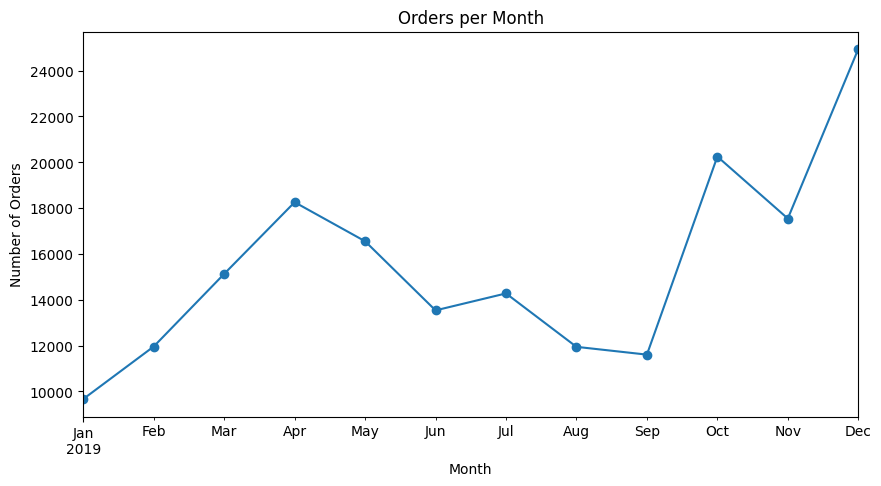

In [16]:
# Monthly order trend (line chart)
plt.figure(figsize=(10,5))
orders_per_month.plot(kind='line', marker='o')
plt.ylabel("Number of Orders")
plt.xlabel("Month")
plt.title("Orders per Month") 
plt.show()

## Monthly Order Trends

The monthly order analysis reveals clear seasonal patterns throughout the year.

Key findings:

- Order volume increased steadily from January to April.
- A decline in orders occurred between May and September.
- Sales activity recovered strongly during the final quarter.
- December recorded the highest number of orders with 24,944 transactions.
- January recorded the lowest number of orders with 9,665 transactions.

These findings indicate a strong seasonal effect. The substantial increase in the final quarter suggests that holiday shopping and year-end promotions had a major influence on customer purchasing behavior.

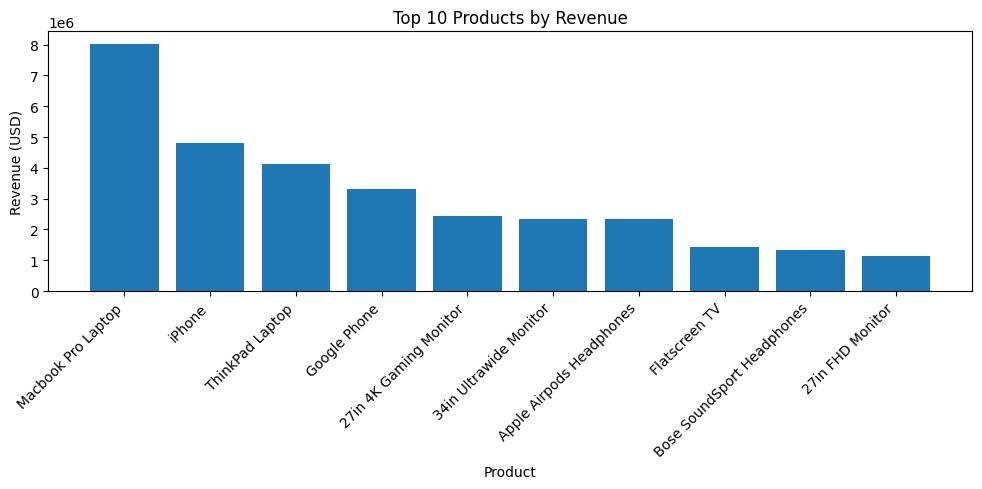

In [17]:
# Top revenue-generating products (Bar chart)

plt.figure(figsize=(10,5))

plt.bar(top_products_revenue.index, top_products_revenue.values)

plt.ylabel("Revenue (USD)")
plt.xlabel("Product")
plt.title("Top 10 Products by Revenue")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

## Top Revenue-Generating Products

The chart highlights the products that generated the highest total revenue during 2019.

Key findings:

- The **MacBook Pro Laptop** generated the highest revenue with approximately **8.03 million USD**.
- The **iPhone** ranked second with approximately **4.79 million USD**.
- The **ThinkPad Laptop** and **Google Phone** also contributed significantly to overall sales revenue.
- High-priced electronic devices dominate the revenue ranking despite lower sales quantities compared to accessories.
- Products such as charging cables and batteries were among the most frequently sold items but generated considerably lower revenue.

These results show that premium electronic devices were the main drivers of revenue, while lower-priced accessories primarily contributed through high sales volume.

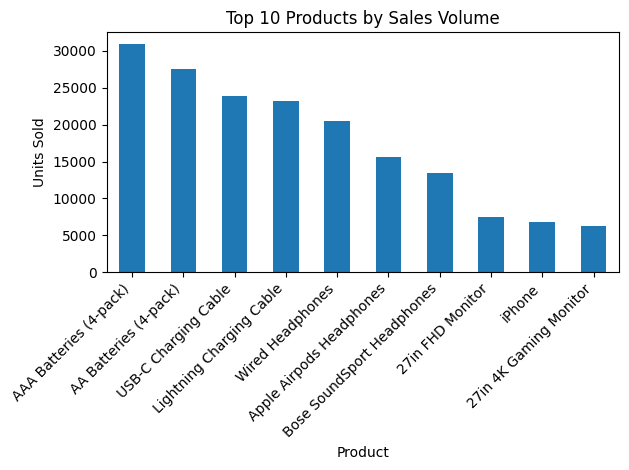

In [18]:
# Top-selling products (Bar chart)

top_products_quantity.plot(kind="bar")

plt.ylabel("Units Sold")
plt.xlabel("Product")
plt.title("Top 10 Products by Sales Volume")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

## Top-Selling Products

The chart displays the ten products with the highest sales volume in 2019.

Key findings:

- **AAA Batteries (4-pack)** were the best-selling product with 30,981 units sold.
- **AA Batteries (4-pack)** ranked second with 27,615 units sold.
- **USB-C Charging Cables** and **Lightning Charging Cables** were also among the most frequently purchased products.
- Accessories dominate the ranking, indicating a consistently high customer demand for low-cost electronic add-ons.
- Premium products such as smartphones and monitors generated strong sales but appeared lower in the ranking due to lower purchase frequency.

These results suggest that accessories represent high-volume products, while premium electronics contribute more strongly to overall revenue.

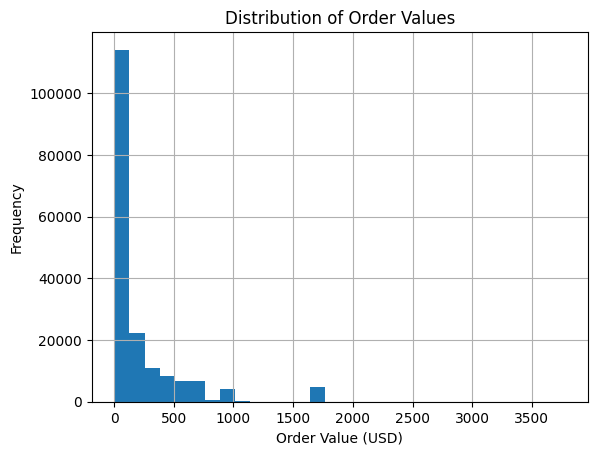

In [19]:
# Order value distribution (Histogram)

# Calculate total order value per order
order_values = (
    df_sales_cleaned.groupby("Order ID")["Total Sales"]
    .sum()
)

# Create histogram
order_values.plot(kind="hist", bins=30)

plt.xlabel("Order Value (USD)")
plt.ylabel("Frequency")
plt.title("Distribution of Order Values")

plt.grid(True)
plt.show()

## Distribution of Order Values

The histogram illustrates the distribution of order values across all customer purchases.

Key findings:

- Most orders are concentrated in the lower order value range.
- High-value orders occur less frequently and form the upper tail of the distribution.
- The distribution is not uniform, indicating that customers typically purchase a small number of products per order.
- A limited number of expensive transactions contribute disproportionately to total revenue.

These findings suggest that the business relies on a large volume of low- and medium-value orders, while a smaller number of premium purchases generate a significant share of overall revenue.

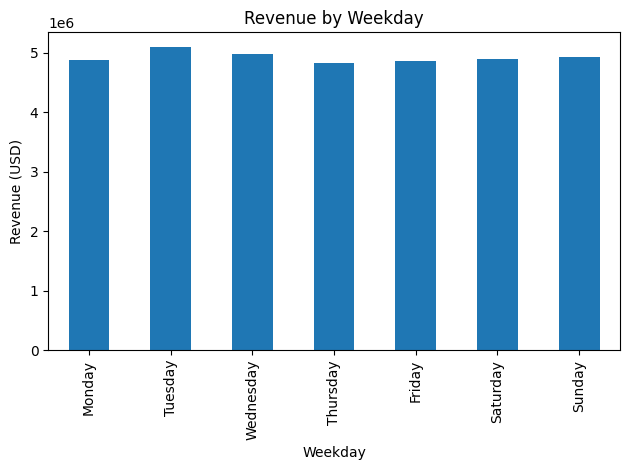

In [20]:
# Revenue by weekday (Bar chart)

# Extract weekday
df_sales_cleaned["Weekday"] = df_sales_cleaned["Order Date"].dt.day_name()

# Define weekday order
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
                 "Friday", "Saturday", "Sunday"]

# Calculate revenue by weekday
revenue_by_weekday = (
    df_sales_cleaned.groupby("Weekday")["Total Sales"]
    .sum()
    .reindex(weekday_order)
)

revenue_by_weekday.plot(kind="bar")

plt.ylabel("Revenue (USD)")
plt.xlabel("Weekday")
plt.title("Revenue by Weekday")
plt.tight_layout()
plt.show()

## Revenue by Weekday

The bar chart compares total revenue generated on each weekday.

Key findings:

- Revenue is distributed relatively evenly across all weekdays.
- Tuesday generated the highest revenue with approximately **5.09 million USD**.
- Thursday generated the lowest revenue with approximately **4.83 million USD**.
- The difference between the strongest and weakest weekday is relatively small.
- No single weekday dominates overall sales performance.

These results suggest that customer purchasing behavior remains relatively stable throughout the week, with only minor fluctuations in daily revenue.

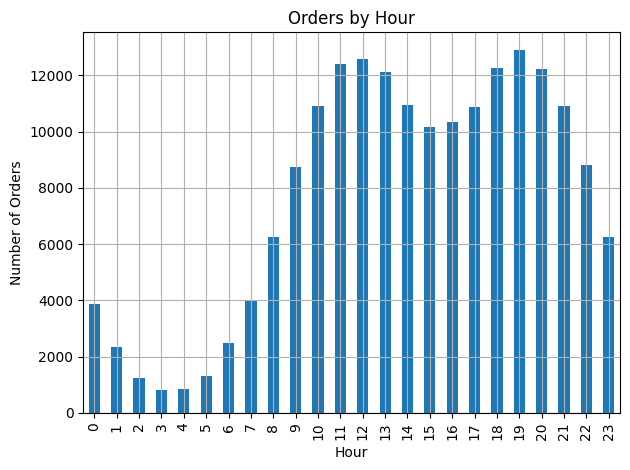

In [21]:
# Orders by Hour (Bar chart)

# Extract hour from order date
df_sales_cleaned["Hour"] = df_sales_cleaned["Order Date"].dt.hour

# Count orders per hour
orders_per_hour = (
    df_sales_cleaned.groupby("Hour")["Order ID"]
    .count()
)

# Plot
orders_per_hour.plot(kind="bar")

plt.xlabel("Hour")
plt.ylabel("Number of Orders")
plt.title("Orders by Hour")
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

## Orders by Hour

The bar chart shows how customer orders are distributed throughout the day.

Key findings:

- Order activity is not evenly distributed across the 24-hour period.
- Sales activity is lowest during the night and early morning hours.
- Order volume increases steadily during the morning.
- The highest number of orders occurs during typical daytime and evening shopping hours.
- Customer activity declines again later in the evening.

These results indicate that customers are most likely to place orders during regular waking and working hours, while demand is significantly lower overnight. Understanding peak ordering times can support staffing, marketing campaigns, and operational planning.

## Results of the Data Visualization

The visualizations reveal several important sales patterns throughout 2019.

Order activity increased over the course of the year, reaching a clear peak in December. This suggests a strong seasonal effect during the holiday shopping period.

The product analysis shows that accessories such as batteries and charging cables were the most frequently purchased items. However, the highest revenue was generated by premium products including laptops, smartphones, and monitors.

The distribution of order values is strongly right-skewed. Most orders fall within a lower price range, while a relatively small number of high-value purchases contribute a substantial share of total revenue.

Revenue is distributed relatively evenly across weekdays, indicating stable customer purchasing behavior throughout the week. In contrast, the hourly analysis reveals clear peaks around midday and during the early evening hours, reflecting typical daily shopping patterns.

Overall, the analysis highlights the importance of seasonality, product mix, and customer purchasing behavior in driving sales performance.

# Time Series Analysis

To further examine sales development over time, a time series analysis was performed using the `seasonal_decompose` function from `statsmodels`.

The analysis includes the following steps:

- Aggregating sales data to daily revenue
- Applying seasonal decomposition with a 30-day period
- Separating the time series into trend, seasonal, and residual components
- Interpreting the resulting patterns in daily revenue

In [22]:
# Daily revenue aggregation

df_sales_cleaned["Order Day"] = df_sales_cleaned["Order Date"].dt.date

daily_revenue = (
    df_sales_cleaned.groupby("Order Day")["Total Sales"]
    .sum()
)

daily_revenue.index = pd.to_datetime(daily_revenue.index)

daily_revenue.head(10)

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    daily_revenue,
    model="additive",
    period=30
)

## Daily Revenue Aggregation

To prepare the dataset for time series analysis, sales transactions were aggregated at the daily level.

The original order timestamps contained both date and time information. Therefore, only the date component was used to calculate total daily revenue.

The resulting daily revenue series serves as the input for the seasonal decomposition analysis.

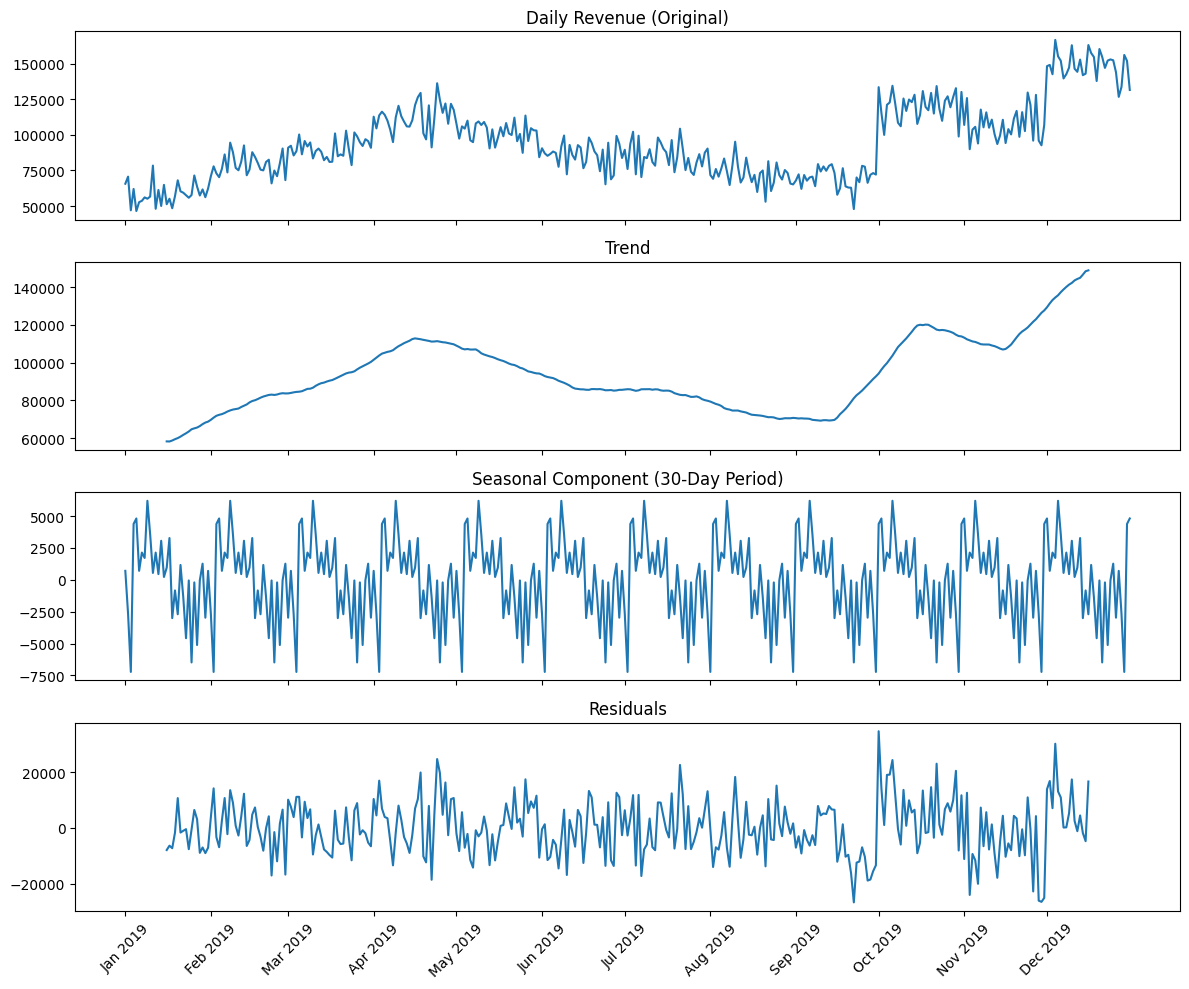

In [23]:
# Visualize seasonal decomposition results

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# 1. Original time series
axes[0].plot(daily_revenue.index, daily_revenue)
axes[0].set_title("Daily Revenue (Original)")

# 2. Trend component
axes[1].plot(daily_revenue.index, decomposition.trend)
axes[1].set_title("Trend")

# 3. Seasonal component
axes[2].plot(daily_revenue.index, decomposition.seasonal)
axes[2].set_title("Seasonal Component (30-Day Period)")

# 4. Residual component
axes[3].plot(daily_revenue.index, decomposition.resid)
axes[3].set_title("Residuals")

# Improve x-axis readability with monthly markers
xticks = pd.date_range(
    start=daily_revenue.index.min(),
    end=daily_revenue.index.max(),
    freq="MS"
)

axes[3].set_xticks(xticks)
axes[3].set_xticklabels(xticks.strftime("%b %Y"), rotation=45)

plt.tight_layout()
plt.show()

## Seasonal Decomposition

The daily revenue time series was decomposed into three main components:

- **Trend:** the long-term movement in daily revenue
- **Seasonality:** repeating patterns within the selected 30-day period
- **Residuals:** irregular fluctuations that are not explained by trend or seasonality

The decomposition shows a clear upward trend toward the end of the year, especially in the final quarter. This supports the earlier finding that sales activity increased strongly during the holiday shopping period.

The seasonal component indicates recurring short-term fluctuations in daily revenue. The residuals show irregular variation, suggesting that some daily sales peaks and drops cannot be fully explained by trend or seasonality alone.

In [24]:
# Aggregate monthly revenue

monthly_revenue = (
    df_sales_cleaned
    .set_index("Order Date")["Total Sales"]
    .resample("MS")
    .sum()
)

monthly_revenue.head()

Order Date
2019-01-01    1812742.87
2019-02-01    2200078.08
2019-03-01    2804973.35
2019-04-01    3389217.98
2019-05-01    3150616.23
Freq: MS, Name: Total Sales, dtype: float64

## Monthly Revenue Aggregation

To support a higher-level time series analysis, daily sales transactions were aggregated into monthly revenue totals.

The order date was used as the time index, and all sales within each month were summed to create a monthly revenue series.

This monthly aggregation helps reveal broader seasonal patterns and long-term trends that may be less visible in daily data.

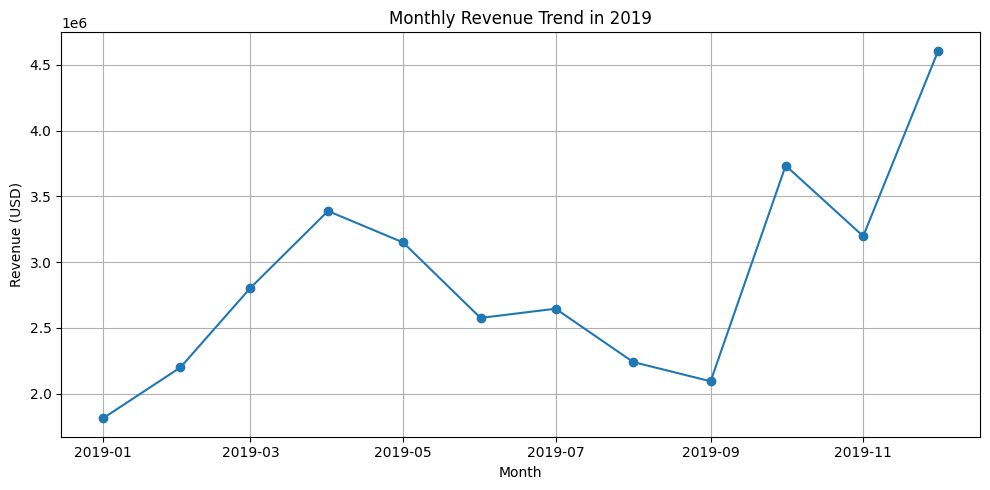

In [25]:
# Monthly revenue trend

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Revenue (USD)")
plt.title("Monthly Revenue Trend in 2019")
plt.grid(True)

plt.tight_layout()
plt.show()

## Monthly Revenue Trend

The monthly revenue trend confirms the seasonal patterns identified earlier in the analysis.

Revenue increased steadily during the first months of the year, followed by moderate fluctuations during the summer period. A strong increase can be observed in the final quarter, with the highest revenue levels reached toward the end of the year.

This pattern suggests that seasonal events and holiday shopping periods had a significant impact on customer purchasing behavior.

# Conclusion

The sales analysis revealed clear temporal and product-related patterns in customer purchasing behavior.

Both the daily and monthly time series analyses showed a strong increase in revenue toward the end of the year, indicating a significant holiday-season effect. The final quarter, particularly November and December, generated the highest sales activity and revenue.

At the product level, a clear distinction emerged between sales volume and revenue contribution. Low-cost accessories such as batteries and charging cables were sold most frequently, while high-value products including laptops, smartphones, and monitors generated the largest share of revenue.

# Marketing Strategy Recommendations

Based on these findings, several practical marketing strategies can be recommended.

Marketing campaigns should focus strongly on the final quarter of the year, as this period offers the highest revenue potential. Seasonal events such as Black Friday, Cyber Monday, and holiday shopping periods should be leveraged through targeted promotions and advertising campaigns.

Early promotional activities during autumn could further strengthen sales performance by encouraging customers to complete purchases before competitors launch their seasonal campaigns.

Throughout the year, smaller promotional campaigns may help increase overall revenue. Product bundles combining frequently purchased accessories with higher-value products could be used to increase the average order value.

The analysis also suggests that marketing investments during the summer months may generate lower returns compared to the final quarter of the year.

From a timing perspective, advertisements should be scheduled during periods of higher customer activity, particularly around midday and during the early evening hours. Since revenue levels were relatively consistent across weekdays, continuous marketing efforts are likely to be more effective than focusing on specific days of the week.